# 11章 確認応答と再送制御

本章では、前章に続いてTCPを扱います。
特に、TCPの信頼性を実現するための確認応答と再送制御の仕組みについて学習します。
前章でコネクション確立について学びましたが、コネクションを確立しただけではパケットの到達を保証することはできません。
確実にパケットを届けるためには、どのパケットが届き、どのパケットが届いていないかを識別し、失われたパケットを再送するための仕組みが必要です。
本章では、これを実現するための仕組みを実装していきます。

## 確認応答とシーケンス番号

### 確認応答とは

前章で学んだ通り、TCPは信頼性の高い通信を実現するためのプロトコルです。
エンドノード間でコネクションを確立した上で、データの確実な到達を保証するための仕組みが確認応答（ACK：Acknowledgment）です。
すなわち確認応答とは、受信側がデータを正しく受け取ったことを送信側に通知するためのメッセージです。
送信側は、ACKを受け取ることで、データが正常に届いたことを確認できます。
もし一定時間内にACKが返ってこない場合、送信側はデータが失われたと判断し、再送制御によって再度データを送信します。

### シーケンス番号

ACKによってデータが届いたことが分かるとして、実際には「どのパケットが届いたか（届いていないか）」を知る必要があります。
それを実現するのがシーケンス番号です。
TCPでは、送信するデータにシーケンス番号を割り当てることで、データの順序を管理しています。
シーケンス番号は、送信されるデータのバイト数を表しており、送信側と受信側の両方で管理されます。
受信側は、受け取ったデータのシーケンス番号をACKに含めて送信側に返します。
送信側はACK内のシーケンス番号の値をチェックすることで、受信側がどこまでのデータを正常に受け取ったのかを知ることができます。

要するにシーケンス番号は、以下のような役割を果たします：

1. データの順序管理：シーケンス番号を使って、送信されるデータの順序を管理します。受信側は、シーケンス番号を元にデータを正しい順序に並べ替えることができます。

2. 重複データの検出：受信側が同じシーケンス番号のデータを複数回受け取った場合、重複データとして処理されます。

3. 欠落データの検出：受信側が期待するシーケンス番号のデータを受け取れなかった場合、データの欠落が発生したと判断されます。

### ACK番号

TCP通信において、データパケットの正確な受信を確認するためには、受信側から送信側へ「どのデータまで正しく受け取ったか」を伝える仕組みが必要です。
これを実現するためにACK番号（確認応答番号）が使用されます。
ACK番号は、受信側が次に期待するデータの最初のバイトのシーケンス番号を示し、これにより送信側は受信側がどこまでのデータを受け取ったかを知ることができます。

ACK番号は以下のような役割を果たします：

- データ受信の確認：ACK番号を使って、受信側がどのデータまで受け取ったかを送信側に通知します。これにより、送信側は未受信のデータがある場合、再送を行うことができます。

- フロー制御：送信側は、受信側からのACK番号を基に、受信側の処理速度や受信バッファの空き状況を推測し、データ送信の速度を調整することができます。

- 信頼性の高い通信の確保：受信側が正しくデータを受け取ったことをACK番号を通じて送信側が確認できるため、TCPは信頼性の高い通信を保証することができます。

つまりACK番号により、送信側と受信側は同期を取りながらデータの送受信を効率的に行うことができます。


### 既存クラスのインポート
前章と同様に、本書のコードをアップロードしてあるGitHubレポジトリから、必要なファイルをインポートするため、以下のコードブロックを実行してください。


In [ ]:
import sys

!git clone https://github.com/flyby-yunakayama/network-simulator.git
sys.path.insert(0,'/content/network-simulator')

fatal: destination path 'network-simulator' already exists and is not an empty directory.


### `Node`クラスのアップデート

#### TCPパケット受信時の処理の改良

前章ではコネクション確立のみを扱っていました。
本章の範囲では、これを拡張して、コネクション確立からデータパケットの送受信までを実装します。

`process_TCP_packet`メソッドでは、TCPパケットの受信処理を担当し、TCPプロトコルの様々なフェーズ（接続確立、データ転送、接続終了）を管理します。

- SYN：接続を開始する意志を示すために送信される。このフラグを持つパケットの受信は、新しい接続の要求として処理される。

- SYN-ACK：SYNパケットを受信したノードが、接続を受け入れる意志と、SYNパケットの受領を確認するために送信する。このメソッドでは、SYNパケットを受信した場合、対応するSYN-ACKパケットの送信を行います。

- ACK：SYN-ACKパケットの受領を確認し、接続確立を完了するために送信される。

- PSH（Push）：即時のデータ処理を要求する。データパケットの受信と同時にアプリケーションにデータを渡すよう指示する。このメソッドでは、PSHフラグを持つパケットを処理し、対応するACKを送信して受信を確認します。

- FIN：接続を終了したいことを示す。このフラグを持つパケットの受信は、接続の終了処理として扱われる。

メソッドの処理フローをまとめると以下です。
最初に、パケットが現在のノード宛てかどうかをMACアドレスとIPアドレスで検証します。
パケットの到着をログに記録し、到着時刻を設定します。
パケットヘッダー内のフラグを検査し、適切な処理を実行します。
SYNフラグを受信した場合、新しい接続の確立処理を開始します。
ACKフラグの処理では、以前の通信の確認応答を処理します。
PSHフラグを持つデータパケットを受信した場合、データの処理を行い、確認応答を送信します。
FINフラグを受信した場合、接続の終了処理を行います。

```
def process_TCP_packet(self, packet):
    # パケットがこのノード宛てかどうかをMACアドレスで確認
    if packet.header["destination_mac"] == self.mac_address:
        # パケットがこのノード宛てかどうかをIPアドレスで確認
        if packet.header["destination_ip"] == self.ip_address:
            # パケットが到着したことをログに記録
            self.network_event_scheduler.log_packet_info(packet, "arrived", self.node_id)
            # パケットが到着した時刻を設定
            packet.set_arrived(self.network_event_scheduler.current_time)

            # パケットのTCPフラグを確認するための処理
            flags = packet.header.get('flags', '')

            # SYNパケットの処理
            if "SYN" in flags:
                # SYN-ACKパケットを受信した場合
                if "ACK" in flags:
                    # TCP接続の情報を更新
                    self.establish_TCP_connection(packet)
                    # ACKを返信
                    self.send_TCP_ACK(packet)
                    # データパケットを送信
                    self.send_tcp_data_packet(packet)
                else:
                    # SYN-ACKを送信
                    self.send_TCP_SYN_ACK(packet)
                return

            # ACKパケットの処理
            if "ACK" in flags:
                # 受信したACKの処理
                self.handle_acknowledgement(packet)

            # PSHパケットの処理（データパケット）
            if "PSH" in flags:
                # ACK番号を更新
                self.update_ACK_number(packet)
                # ACKを返信
                self.send_TCP_ACK(packet)
                # データパケットを処理
                self.process_data_packet(packet)

            # FINパケットの処理（接続終了）
            if "FIN" in flags:
                # TCP接続を終了
                self.terminate_TCP_connection(packet)

        else:
            # パケットがこのノード宛てではない場合ドロップ
            self.network_event_scheduler.log_packet_info(packet, "dropped", self.node_id)
```

#### ACK番号の更新

このメソッドは、受信したTCPパケットのシーケンス番号を基に、ACK番号を更新するプロセスを担います。ここでのACK番号は、受信者が次に期待するシーケンス番号を送信者に通知するために使用されます。この通知によって、送信者はどのパケットが正常に受信され、どのパケットが再送が必要なのかを判断できます。

- 接続の識別：各TCP接続は、送信元のIPアドレスとポート番号によって一意に識別されます。このメソッドでは、受信したパケットからこれらの情報を取得して、対象の接続を特定します。

- シーケンス番号の取得と記録：受信したパケットに含まれるシーケンス番号とペイロードの長さを基に、どのデータが受信されたかを追跡します。この情報は、次に期待するシーケンス番号を決定するために使用されます。

- ACK番号の更新：現在のACK番号と比較して、受信したシーケンス番号が連続している場合（つまり、受信すべきすべてのパケットが順序どおりに受信されている場合）、ACK番号を更新します。これは、送信者に対して「この番号までのデータは正常に受信した」と通知することを意味します。

```
def update_ACK_number(self, packet):
    # 接続を一意に識別するためのキー（送信元IPアドレスとポート番号の組み合わせ）を作成
    connection_key = (packet.header["source_ip"], packet.header["source_port"])
    
    # このキーに対応するTCP接続情報がない場合、何もせずにメソッドを終了
    if connection_key not in self.tcp_connections:
        return

    # パケットのシーケンス番号とペイロード（実際に送信されたデータ）の長さを取得
    received_sequence_number = packet.header["sequence_number"]
    payload_length = len(packet.payload)

    # 現在この接続で確認済みの最後のシーケンス番号（ACK番号）を取得
    current_ack_number = self.tcp_connections[connection_key]["acknowledgment_number"]

    # 受信したシーケンス番号を記録していくセットを取得または新規作成
    received_sequence_numbers = self.tcp_connections[connection_key].setdefault('received_sequence_numbers', set())
    # ペイロード長に応じて受信したシーケンス番号をセットに追加
    for seq in range(received_sequence_number, received_sequence_number + payload_length):
        received_sequence_numbers.add(seq)

    # 連続して受信した最後のシーケンス番号（次に期待するシーケンス番号）を求める
    next_expected_seq = current_ack_number
    while next_expected_seq in received_sequence_numbers:
        next_expected_seq += 1

    # ACK番号を更新（次に期待するシーケンス番号が現在のACK番号と異なる場合のみ）
    if next_expected_seq != current_ack_number:
        self.tcp_connections[connection_key]["acknowledgment_number"] = next_expected_seq
        if self.network_event_scheduler.tcp_verbose:
            # ACK番号が更新されたことをログ出力
            print(f"Updated ACK number to {next_expected_seq} for connection {connection_key}.")
    else:
        # 期待するシーケンス番号が見つからなかった場合は、ACK番号を更新しない
        pass
```

#### データパケットの送信

TCPデータパケットを生成するメソッドも作成します。
`send_tcp_data_packet`メソッドは、確立されたTCP接続を通じてデータパケットを送信し、その送信プロセスを管理します。
TCPの特性上、データの順序正確性、紛失したデータの再送、受信確認（ACK）によるフロー制御などが重要です。

- 接続の識別：送信するデータパケットが属するTCP接続を、送信元IPアドレスとポート番号によって識別します。

- トラフィック情報の確認：該当するTCP接続のトラフィック情報を確認し、データ送信のためのパラメータ（ペイロードサイズ、終了時刻など）を取得します。

- 送信ウィンドウの管理：TCPのフロー制御の一環として、送信ウィンドウのサイズを考慮し、送信が可能な状態であるかを判断します。ウィンドウサイズは、一度に送信できるデータ量を制限し、ネットワークの混雑を防ぐために使用されます。

- データの送信：設定されたパラメータに基づいて、実際にデータパケットを送信します。ここでは、PSH（Push）フラグを使用して、受信側にデータの即時処理を促します。

- シーケンス番号の更新：データを送信した後、送信したデータの量に応じてシーケンス番号を更新します。シーケンス番号は、送信される各パケットを一意に識別し、データの順序を保持するために重要です。

```
def send_tcp_data_packet(self, packet, attempt=0):
    # 接続識別子を作成（送信元IPとポート番号）
    connection_key = (packet.header["source_ip"], packet.header["source_port"])
    
    # 接続が既存のTCP接続に含まれているか確認
    if connection_key in self.tcp_connections:
        # 接続情報にトラフィック情報が含まれているか確認
        if 'traffic_info' not in self.tcp_connections[connection_key]:
            # トラフィック情報が見つからない場合は、処理を終了
            if self.network_event_scheduler.tcp_verbose:
                print(f"No traffic info found for {connection_key}")
            return

        # トラフィック情報の取得
        traffic_info = self.tcp_connections[connection_key]['traffic_info']
        # 現在時刻がトラフィック情報の終了時刻より前であることを確認
        if self.network_event_scheduler.current_time < traffic_info['end_time']:
            # 送信ウィンドウが初期化されていなければ初期化
            if connection_key not in self.windows:
                self.windows[connection_key] = {}

            # ウィンドウサイズを超えていないか確認
            if len(self.windows[connection_key]) < self.window_size:
                # 送信するデータとペイロードサイズの取得
                remaining_data = self.tcp_connections[connection_key]['data']
                payload_size = traffic_info['payload_size']
                data_to_send = remaining_data[:payload_size]

                # 送信するパケットのパラメータを設定
                data_packet_kwargs = {
                    "source_port": packet.header["destination_port"],
                    "destination_port": packet.header["source_port"],
                    "sequence_number": self.tcp_connections[connection_key]['sequence_number'],
                    "acknowledgment_number": self.tcp_connections[connection_key]['acknowledgment_number'],
                    "flags": "PSH"
                }

                # データパケットを送信
                self._send_tcp_packet(
                    destination_ip=packet.header["source_ip"],
                    destination_mac=packet.header["source_mac"],
                    data=data_to_send,
                    **data_packet_kwargs
                )

                # 送信後、残りのデータとシーケンス番号を更新
                self.tcp_connections[connection_key]['data'] = remaining_data[payload_size:]
                self.tcp_connections[connection_key]['sequence_number'] += len(data_to_send)

                # 再帰的にこのメソッドを呼び出し、残りのデータも送信する
                self.send_tcp_data_packet(packet, attempt)
```

#### TCPトラフィック設定の修正

前章までは、UDPのように適当な間隔でパケット生成をコールしていましたが、実際のTCPの挙動とはかなり異なりました。
シーケンス番号を用いたデータ送信の管理を行うため、まとめてデータを生成しておき、それをACKに応じて順番に送っていくように修正します。

- 接続の識別: TCP接続は、送信元と宛先のIPアドレスおよびポート番号によって一意に識別されます。このメソッドでは、ランダムに選択されたポート番号と宛先IPアドレスを使用して、新しい接続のキーを作成します。

- データの初期化: 送信するデータ量は、指定されたビットレートと持続時間から計算されます。この計算によって生成されたデータは、接続の初期状態として設定されます。

- トラフィック情報: ビットレート、ペイロードサイズ、ヘッダーサイズ、そしてトラフィックのバースト性（burstiness）などのトラフィックパラメータが設定されます。これらのパラメータは、データ送信の特性を定義し、TCP接続の性能をシミュレートする際に重要です。

- SYNパケットの送信: TCP接続の確立は、SYNフラグを持つパケットの送信によって開始されます。この初期ステップは、接続の確立を宛先に通知し、接続の確立フェーズの最初の部分を形成します。

```
def set_tcp_traffic(self, destination_ip, bitrate, start_time, duration, header_size, payload_size, burstiness=1.0, protocol="TCP"):
    # トラフィックが終了する時間を計算
    end_time = start_time + duration
    # ソースポートと宛先ポートをランダムに選択
    source_port = self.select_random_port()
    destination_port = self.select_random_port()  # 実際の使用では、適切な宛先ポートを指定する必要があります
    
    # TCP接続を識別するためのキーを生成
    connection_key = (destination_ip, destination_port)
    
    # 新しいTCP接続を設定する
    if connection_key not in self.tcp_connections:
        # データ量をビットレートと持続時間から計算し、初期データを生成
        data = b'X' * (int(bitrate * duration) // 8)
        # コネクション情報を初期化
        self.initialize_connection_info(connection_key=connection_key, sequence_number=randint(1, 10000), data=data)
    
    # トラフィック情報を設定
    self.tcp_connections[connection_key]['traffic_info'] = {
        'end_time': end_time,
        'payload_size': payload_size,
        'header_size': header_size,
        'bitrate': bitrate,
        'burstiness': burstiness,
        'next_sequence_number': self.tcp_connections[connection_key]['sequence_number']  # 次に送信するシーケンス番号
    }

    # 最初のSYNパケットを送信して、TCP接続の確立を開始
    self.send_packet(destination_ip, b"", protocol="TCP", source_port=source_port, destination_port=destination_port, flags="SYN")
```


### シーケンス番号の確認

アップデートした`Node`クラスを用いて、TCPトラフィックを送受信し、シーケンス番号およびACK番号の挙動を確認してみましょう。
`tcp_verbose=True`を設定することで、TCPパケットのフラグのほか、シーケンス番号とACK番号も表示されます。
以下の例では、分かり易いように`payload_size=1000`と設定しています。


fatal: destination path 'network-simulator' already exists and is not an empty directory.


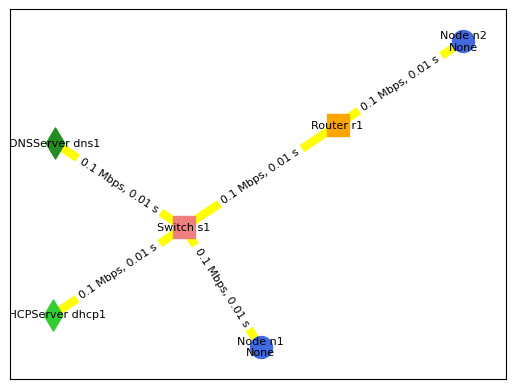

Node n1 has been assigned the IP address 192.168.1.1/24.
Node n1 has been assigned the DNS server IP address 192.168.1.200/24.
n1 DNS record added: www.example.com -> 192.168.2.1/24
Initiating TCP handshake: Sending SYN to 192.168.2.1/24:5693 from port 19737
Sending TCP packet from n1 to 192.168.2.1/24:5693 with Flags: SYN, Data Length: 0, Sequence Number: 9847, Acknowledgment Number: 0, 
Connection state updated to SYN_SENT for 192.168.2.1/24:5693
Sending TCP packet from n2 to 192.168.1.1/24:19737 with Flags: SYN,ACK, Data Length: 0, Sequence Number: 8746, Acknowledgment Number: 9848, 
TCP connection state updated to ESTABLISHED for ('192.168.1.1/24', 19737)
TCP connection state updated to ESTABLISHED for ('192.168.2.1/24', 5693)
Sending TCP packet from n1 to 192.168.2.1/24:5693 with Flags: ACK, Data Length: 0, Sequence Number: 9848, Acknowledgment Number: 8747, 
Sending TCP packet from n1 to 192.168.2.1/24:5693 with Flags: PSH, Data Length: 100, Sequence Number: 9848, Acknowledgment 

In [ ]:
import sys

!git clone https://github.com/flyby-yunakayama/network-simulator.git
sys.path.insert(0,'/content/network-simulator')

from sec11a.NetworkEventScheduler import NetworkEventScheduler
from sec11a.Node import Node
from sec11a.Switch import Switch
from sec11a.Router import Router
from sec11a.Server import DNSServer, DHCPServer
from sec11a.Link import Link

nes = NetworkEventScheduler(log_enabled=True, verbose=False, tcp_verbose=True)

# ノードとルータの設定
node1 = Node(node_id="n1", ip_address="192.168.1.0/24", network_event_scheduler=nes)  # DHCP利用
node2 = Node(node_id="n2", ip_address="192.168.2.1/24", network_event_scheduler=nes)  # IPアドレスを静的に設定
switch1 = Switch(node_id="s1", ip_address="192.168.1.240/24", network_event_scheduler=nes)
router1 = Router(node_id="r1", ip_addresses=["192.168.1.254/24", "192.168.2.254/24"], network_event_scheduler=nes)
dns1 = DNSServer(node_id="dns1", ip_address="192.168.1.200/24", network_event_scheduler=nes)
dhcp1 = DHCPServer(node_id="dhcp1", ip_address="192.168.1.250/24", dns_server_ip="192.168.1.200/24", start_cidr="192.168.1.0/24", network_event_scheduler=nes)

# リンクの設定
link1 = Link(node1, switch1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link2 = Link(switch1, router1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link3 = Link(dns1, switch1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link4 = Link(dhcp1, switch1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link5 = Link(node2, router1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)

# ネットワークのトポロジを描画
nes.draw()

# DNSサーバに対してDNSレコード設定
dns1.add_dns_record("www.example.com", "192.168.2.1/24")

# DHCPサーバに対して使用済みIPアドレス登録
used_ips = ["192.168.1.240/24", "192.168.1.254/24", "192.168.1.200/24", "192.168.1.250/24"]
dhcp1.mark_ips_as_used(used_ips)

# 通信アプリケーションの設定
node1.start_tcp_traffic(destination_url="www.example.com", bitrate=80000, start_time=1.0, duration=2.0, header_size=50, payload_size=1000)

# イベントスケジューラを実行
nes.run_until(5.0)

# フォワーディングテーブルやルーティングテーブルを確認
node1.print_arp_table()
node1.print_url_to_ip_mapping()
node1.print_tcp_connections()
router1.print_arp_table()
router1.print_routing_table()
node2.print_arp_table()
node2.print_tcp_connections()

# 結果を確認
nes.generate_summary(nes.packet_logs)
#nes.generate_throughput_graph(nes.packet_logs)
#nes.generate_delay_histogram(nes.packet_logs)


## 再送制御

### 再送制御とは

上記の実装では、シーケンス番号は単純に増加していくだけでした。
つまり、データ内のどの部分かを識別することはできるようになったものの、相手がどのデータの受信に成功したかに関わらず、順番にデータを送っているだけです。
これではデータ到達性の保証はできません。
そこで必要となるのが再送制御です。

### 重複ACK
TCPは、データ転送の信頼性を保証するために、パケットの紛失や順序の乱れを検出し、適切に対処する機能を備えています。
重複ACKは、送信側に対してパケットロスが発生した可能性があることを早期に通知し、迅速なパケットの再送によってデータ転送の遅延を最小限に抑えるための仕組みです。

#### `process_TCP_packet`メソッドのアップデート

`process_TCP_packet`メソッドを改良し、重複ACKに関する処理を行います。
TCPにおいて重複ACK（Acknowledgement）は、ネットワーク上でパケットの紛失が発生した可能性があることを示す重要な指標です。このメカニズムにより、信頼性の高いデータ転送を維持しつつ、ネットワークの状態に応じた効率的なパケットの再送を可能にします。

新たに導入された`check_duplication_threshold`メソッドは、特定のパケットに対して受け取ったACKの数が設定された閾値を超えた場合を検出します。
これは、送信したパケットが途中で失われたか、順序が乱れたことを示唆しており、迅速な再送によって通信の信頼性を保つための重要な手がかりとなります。
閾値を超えた場合、`check_and_retransmit_packets`メソッドによって対象のパケットが再送されます。
重複ACKの閾値を超えない場合でも、通常のACKパケットの処理は継続され、`send_tcp_data_packet`メソッドを通じて新たなデータパケットの送信を試みます。

```
    def process_TCP_packet(self, packet):

            (省略)

                # ACKパケットの処理
                if "ACK" in flags:
                    self.handle_acknowledgement(packet)  # ACKの処理
                    if self.check_duplication_threshold(packet):  # 重複ACKの閾値を超えた場合
                        self.check_and_retransmit_packets(packet)  # パケットの再送
                    else:
                        self.send_tcp_data_packet(packet)  # パケットの送信

```

#### `handle_acknowledgement`メソッド

このメソッドは、TCP通信におけるACK（Acknowledgement、確認応答）の処理に焦点を当てています。ACKは受信側がデータを正しく受け取ったことを送信側に伝える重要なメカニズムです。特に、このメソッドは重複ACKの検出と処理に重点を置いています。

- 重複ACKの検出:受け取ったACKが前回受け取ったACKと同じ番号である場合に重複ACKとしてカウントします。これは、ネットワーク上でデータパケットが失われた可能性があることを示唆しています。

- 重複ACKのカウント管理:重複ACKを受け取るたびに、そのカウントを増やします。初めて新しいACK番号を受け取った場合は、カウントをリセットし、最新のACK番号を記録します。これにより、パケットの紛失が疑われる場合に備えた迅速な対応が可能になります。

- 送信ウィンドウの管理:ACK番号に基づいて送信ウィンドウ内のパケットを確認し、ACKによって確認されたパケットをウィンドウから削除します。これにより、送信ウィンドウの空きが生まれ、新たなデータの送信が可能となります。

- データ再送信の準備:ウィンドウ内で空きができた場合、残っているデータがあればそれを基に新たなパケットを送信します。これにより、効率的なデータ転送が継続されます。

```
    def handle_acknowledgement(self, packet):
        connection_key = (packet.header["source_ip"], packet.header["source_port"])
        ack_number = packet.header["acknowledgment_number"]

        if connection_key not in self.tcp_connections:
            return  # コネクションが存在しない場合は何もしない
        
        if connection_key not in self.windows:
            self.windows[connection_key] = {}  # 必要に応じて初期化、またはreturn文で処理をスキップ

        if self.tcp_connections[connection_key]["last_ack_number"] == ack_number:
            # 重複ACKのカウントを増やす
            self.tcp_connections[connection_key]["duplicate_ack_count"] += 1
        else:
            self.tcp_connections[connection_key]["duplicate_ack_count"] = 1
            self.tcp_connections[connection_key]["last_ack_number"] = ack_number

        # ACK番号に一致するパケットをウィンドウから削除
        for seq, packet_info in list(self.windows[connection_key].items()):
            if packet_info["expected_ack_number"] <= ack_number:
                if self.network_event_scheduler.tcp_verbose:
                    print(f"Removing packet with sequence number {seq} from window for connection {connection_key} due to receiving ACK {ack_number}. Expected ACK was {packet_info['expected_ack_number']}.")
                # タイムアウトイベントのキャンセル
                self.cancel_timeout(connection_key, seq)
                del self.windows[connection_key][seq]

            # ウィンドウに空きができたので、新たなパケットを送信可能
            if self.tcp_connections[connection_key]['data']:
                self.send_tcp_data_packet(packet)
```

#### `check_duplication_threshold`メソッド

このメソッドは、TCPプロトコルのデータ通信における重複ACKの閾値検出機能を提供します。特に、TCPにおいて重複ACKが特定の閾値（通常は3回）に達した場合、これはネットワーク上でのパケットロスが発生した可能性が高いことを示しています。この検出メカニズムは、効率的なパケットの再送を可能にし、通信の信頼性を維持するために重要です。

- 接続の識別: パケットのヘッダー情報から、対象のTCP接続を特定するキー（送信元IPとポート番号の組み合わせ）を生成します。

- 重複ACKカウントの確認: 特定されたTCP接続における重複ACKのカウントを確認します。このカウントは、以前に受信したACKと同じACK番号が再度受信された場合に増加します。

- 閾値の検出: 重複ACKのカウントが設定された閾値（この例では3回）に達したかどうかを判断します。閾値に達した場合は、パケットロスの可能性が高いと判断し、対応する処理（例えばパケットの再送）を行うためのシグナルとしてTrueを返します。

```
def check_duplication_threshold(self, packet):
    # パケットから接続識別情報を生成します（送信元IPアドレスとポート番号の組み合わせ）
    connection_key = (packet.header["source_ip"], packet.header["source_port"])
    
    # 生成した接続キーが既存のTCP接続に含まれているかを確認します
    if connection_key in self.tcp_connections:
        # 既存のTCP接続から、この接続の重複ACKカウントを確認します
        # 重複ACKカウントが3以上に達しているかを確認します（TCPの高速再送信トリガー条件）
        if self.tcp_connections[connection_key]["duplicate_ack_count"] >= 3:
            # 重複ACKの閾値に達した場合、詳細ログが有効であればその情報を出力します
            if self.network_event_scheduler.tcp_verbose:
                # 最後に受信したACK番号を取得します
                last_ack_number = self.tcp_connections[connection_key].get("last_ack_number")
                # ログ出力: 重複ACKの閾値に達したことと、該当するACK番号を表示します
                print(f"Duplicate ACK threshold reached for connection {connection_key} with ACK number {last_ack_number}.")
            # 重複ACKの閾値に達したことを示すためにTrueを返します
            return True
        else:
            # 重複ACKの閾値に達していない場合はFalseを返します
            return False
    # 接続キーがTCP接続に存在しない場合もFalseを返します
    return False
```

#### `check_and_retransmit_packets`メソッド

ネットワーク上でのデータ転送中にパケットロスが発生した場合、またはパケットの順序が乱れた場合に対応するためのパケット再送処理を実行します。

- 接続の特定：処理するパケットから接続識別子（送信元IPアドレスとポート番号の組み合わせ）を取得します。この識別子を使用して、特定のTCP接続を識別します。

- 再送対象のシーケンス番号の特定：次に、find_retransmit_sequence_number関数を呼び出して、再送すべきパケットのシーケンス番号を特定します。この関数は、パケットロスが疑われる最初のパケットのシーケンス番号を返すか、再送が不要であると判断した場合はNoneを返します。

- パケットの再送処理：再送すべきパケットが存在する場合（sequence_numberがNoneではない場合）、retransmit_packet関数を呼び出して該当するパケットの再送を行います。これにより、失われたデータの回復や順序の乱れの修正が行われ、通信の信頼性が保たれます。

- 再送対象パケットの不在の処理：再送すべきパケットが存在しない場合（sequence_numberがNoneの場合）、再送が不要であることを示すメッセージを出力します。

```
def check_and_retransmit_packets(self, packet):
    # パケットから接続識別情報を生成します（送信元IPアドレスとポート番号の組み合わせ）
    connection_key = (packet.header["source_ip"], packet.header["source_port"])
    
    # 再送すべきパケットのシーケンス番号を特定します
    # この関数は、再送を行うべき最初のパケットのシーケンス番号を返します
    # 再送の必要があるパケットがない場合はNoneを返します
    sequence_number = self.find_retransmit_sequence_number(connection_key)
    
    if sequence_number is not None:
        # 再送すべきパケットが存在する場合、指定されたシーケンス番号のパケットを再送します
        self.retransmit_packet(connection_key, sequence_number)
    else:
        # 再送すべきパケットがない場合は、その旨を出力します
        print(f"No packets to retransmit for connection {connection_key}")
```

#### `send_tcp_data_packet`メソッド

データパケット送信時の処理を修正し、再送のために送信パケットを記録しておくようにします。ここで記録される情報には、パケットの宛先IPアドレス、宛先MACアドレス、送信データ、および送信に使用されたパラメータが含まれます。また、このパケットに対して受信者から期待されるACK番号と、パケットの送信試行回数も記録されます。

この記録は、後にパケットの送信状態を確認し、必要に応じて再送処理を行うために利用されます。例えば、期待されるACK番号が受信できなかった場合には、記録された情報を基に該当するパケットを再送することが可能です。これにより、TCP通信におけるデータの信頼性と効率性が保たれることになります。

TCPプロトコルにおけるデータパケットの送信と管理のプロセスは、データ転送の信頼性を確保するために非常に重要です。送信ウィンドウ内にパケット情報を記録することで、送信したデータの追跡と管理が行われ、ネットワークの混雑やパケットロスが発生した場合でも、迅速な再送によって通信の品質を維持することが可能となります。

```
def send_tcp_data_packet(self, packet, attempt=0):

    # 省略

        # 送信したパケット情報を送信ウィンドウに記録します
        sequence_number = self.tcp_connections[connection_key]['sequence_number']  # 送信するデータパケットのシーケンス番号を取得
        expected_ack_number = sequence_number + len(data_to_send)  # 送信データに基づいて、次に期待するACK番号を計算
        self.windows[connection_key][sequence_number] = {  # シーケンス番号をキーとして送信ウィンドウに記録
            "packet_info": {
                'destination_ip': packet.header["source_ip"],  # 宛先IPアドレス
                'destination_mac': packet.header["source_mac"],  # 宛先MACアドレス
                'data': data_to_send,  # 送信するデータ
                'kwargs': data_packet_kwargs  # パケット送信時に使用される追加のパラメータ
            },
            "expected_ack_number": expected_ack_number,  # このパケットに対して次に期待するACK番号
            "attempt": attempt  # このパケットの送信試行回数
        }
```


### 再送制御の確認

パケットロスが生じる条件下で、再送制御の挙動をシミュレーションで確認してみましょう。
シーケンス番号を用いて送信するデータを管理し、受信したACKに記載されているACK番号によって無事に目的地へ到達したかどうかを判断します。
`tcp_verbose=True`に設定することでログが表示されるので、順を追って挙動を確認していきましょう。
なおシーケンス番号などは乱数で定まるようになっているため、実行の度に変化します。


fatal: destination path 'network-simulator' already exists and is not an empty directory.


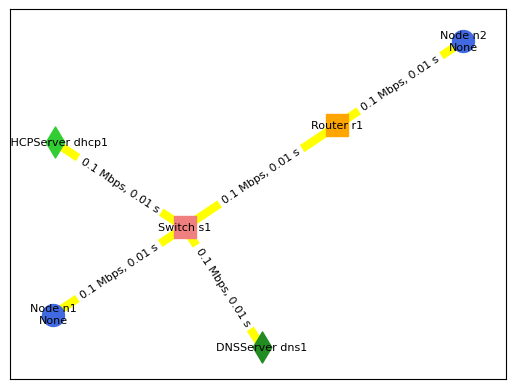

Node n1 has been assigned the IP address 192.168.1.1/24.
Node n1 has been assigned the DNS server IP address 192.168.1.200/24.
n1 DNS record added: www.example.com -> 192.168.2.1/24
Initiating TCP handshake: Sending SYN to 192.168.2.1/24:42600 from port 47402
Sending TCP packet from n1 to 192.168.2.1/24:42600 with Flags: SYN, Data Length: 0, Sequence Number: 3350, Acknowledgment Number: 0, 
Connection state updated to SYN_SENT for 192.168.2.1/24:42600
Sending TCP packet from n2 to 192.168.1.1/24:47402 with Flags: SYN,ACK, Data Length: 0, Sequence Number: 9086, Acknowledgment Number: 3351, 
TCP connection state updated to ESTABLISHED for ('192.168.1.1/24', 47402)
TCP connection state updated to ESTABLISHED for ('192.168.2.1/24', 42600)
Sending TCP packet from n1 to 192.168.2.1/24:42600 with Flags: ACK, Data Length: 0, Sequence Number: 3351, Acknowledgment Number: 9087, 
Sending TCP packet from n1 to 192.168.2.1/24:42600 with Flags: PSH, Data Length: 1000, Sequence Number: 3351, Acknowle

In [ ]:
import sys

!git clone https://github.com/flyby-yunakayama/network-simulator.git
sys.path.insert(0,'/content/network-simulator')

from sec11b.NetworkEventScheduler import NetworkEventScheduler
from sec11b.Node import Node
from sec11b.Switch import Switch
from sec11b.Router import Router
from sec11b.Server import DNSServer, DHCPServer
from sec11b.Link import Link

nes = NetworkEventScheduler(log_enabled=True, verbose=False, tcp_verbose=True)

# ノードとルータの設定
node1 = Node(node_id="n1", ip_address="192.168.1.0/24", network_event_scheduler=nes)  # DHCP利用
node2 = Node(node_id="n2", ip_address="192.168.2.1/24", network_event_scheduler=nes)  # IPアドレスを静的に設定
switch1 = Switch(node_id="s1", ip_address="192.168.1.240/24", network_event_scheduler=nes)
router1 = Router(node_id="r1", ip_addresses=["192.168.1.254/24", "192.168.2.254/24"], network_event_scheduler=nes)
dns1 = DNSServer(node_id="dns1", ip_address="192.168.1.200/24", network_event_scheduler=nes)
dhcp1 = DHCPServer(node_id="dhcp1", ip_address="192.168.1.250/24", dns_server_ip="192.168.1.200/24", start_cidr="192.168.1.0/24", network_event_scheduler=nes)

# リンクの設定
link1 = Link(node1, switch1, bandwidth=100000, delay=0.01, loss_rate=0.1, network_event_scheduler=nes)
link2 = Link(switch1, router1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link3 = Link(dns1, switch1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link4 = Link(dhcp1, switch1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link5 = Link(node2, router1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)

# ネットワークのトポロジを描画
nes.draw()

# DNSサーバに対してDNSレコード設定
dns1.add_dns_record("www.example.com", "192.168.2.1/24")

# DHCPサーバに対して使用済みIPアドレス登録
used_ips = ["192.168.1.240/24", "192.168.1.254/24", "192.168.1.200/24", "192.168.1.250/24"]
dhcp1.mark_ips_as_used(used_ips)

# 通信アプリケーションの設定
node1.start_tcp_traffic(destination_url="www.example.com", bitrate=80000, start_time=1.0, duration=10.0, header_size=50, payload_size=1000)

# イベントスケジューラを実行
nes.run_until(10.0)

# フォワーディングテーブルやルーティングテーブルを確認
node1.print_arp_table()
node1.print_url_to_ip_mapping()
node1.print_tcp_connections()
router1.print_arp_table()
router1.print_routing_table()
node2.print_arp_table()
node2.print_tcp_connections()

# 結果を確認
nes.generate_summary(nes.packet_logs)
#nes.generate_throughput_graph(nes.packet_logs)
#nes.generate_delay_histogram(nes.packet_logs)


#### コネクション確立

このログのセクションは、TCPプロトコルにおける接続確立フェーズ、いわゆる「Three-Way Handshake」のプロセスを示しています。このプロセスは、信頼性の高い通信チャネルを確立するために、TCPが使用する基本的な手順です。

```plaintext
# 1. SYNパケットの送信
Initiating TCP handshake: Sending SYN to 192.168.2.1/24:46232 from port 7358
```
- この行は、TCP接続を開始するためにSYN（同期）パケットを送信するプロセスが開始されたことを示します。SYNパケットは、通信を開始する意志と初期シーケンス番号を相手に通知します。

```plaintext
# 2. SYNパケットの詳細
Sending TCP packet from n1 to 192.168.2.1/24:46232 with Flags: SYN, Data Length: 0, Sequence Number: 6214, Acknowledgment Number: 0,
```
- ここでは、実際にSYNパケットが送信される詳細が記録されています。データ長が0であることから、このパケットにはペイロードデータは含まれておらず、接続の同期を目的としています。

```plaintext
# 3. 接続状態の更新（SYN_SENT）
Connection state updated to SYN_SENT for 192.168.2.1/24:46232
```
- この行は、SYNパケットの送信後、接続状態が「SYN_SENT」に更新されたことを示しています。これは、SYNパケットを送信したが、まだ相手からの応答（SYN-ACK）を受信していない状態です。

```plaintext
# 4. SYN-ACKパケットの受信
Sending TCP packet from n2 to 192.168.1.1/24:7358 with Flags: SYN,ACK, Data Length: 0, Sequence Number: 3317, Acknowledgment Number: 6215,
```
- この部分は、接続を要求した側がSYN-ACKパケットを受信したことを示しています。このパケットには、SYNとACKのフラグがセットされており、初期シーケンス番号としての応答、および受信したSYNパケットのシーケンス番号への確認応答が含まれています。

```plaintext
# 5. 接続状態の更新（ESTABLISHED）
TCP connection state updated to ESTABLISHED for ('192.168.1.1/24', 7358)
TCP connection state updated to ESTABLISHED for ('192.168.2.1/24', 46232)
```
- この二行は、両端点でTCP接続の状態が「ESTABLISHED」（確立済み）に更新されたことを示しています。これは、Three-Way Handshakeが完了し、データ転送の準備が整ったことを意味します。

#### データ送受信

このログセクションは、TCP接続が確立された後のデータ転送フェーズを示しています。ここでのイベントは、データの送受信、ACKによる受信確認、および送信ウィンドウの管理に関連しています。以下に、各ログエントリの概要とその意味を説明します。

```plaintext
# ACKパケットの送信
Sending TCP packet from n1 to 192.168.2.1/24:46232 with Flags: ACK, Data Length: 0, Sequence Number: 6215, Acknowledgment Number: 3318,
```
- このログは、n1ノードがn2ノードへACKパケットを送信していることを示しています。これは、n2ノードから受信したデータ（SYN-ACK）の確認応答です。

```plaintext
# PSHフラグを持つデータパケットの送信
Sending TCP packet from n1 to 192.168.2.1/24:46232 with Flags: PSH, Data Length: 1000, Sequence Number: 6215, Acknowledgment Number: 3318,
```
- ここでは、n1ノードが実際のデータを含むパケットをn2ノードに送信しています。PSHフラグは、受信側に対してこのデータをアプリケーションに直ちに渡すよう指示します。データ長が1000であり、これは送信されるデータの量を示しています。

```plaintext
# データパケットとACKの受信と更新
Received sequence number: 6215, payload length: 1000, current ACK number: 6215
Updated ACK number to 7215 for connection ('192.168.1.1/24', 7358).
```
- このエントリは、n2ノードがn1ノードからデータパケットを受信し、その後でACK番号を更新していることを示しています。これは、受信したデータが次のデータパケットの受信に備えて正しく処理されたことを示しています。

```plaintext
# パケットの送信ウィンドウからの削除
Removing packet with sequence number 6215 from window for connection ('192.168.2.1/24', 46232) due to receiving ACK 7215. Expected ACK was 7215.
```
- このログは、送信ウィンドウから特定のパケットが削除されたことを示しています。これは、そのパケットに対するACKが受信され、データが正しく受け取られたことを意味します。これにより、ウィンドウ内で新たなデータパケットの送信が可能になります。

#### データ再送

このログセクションでは、TCPプロトコルにおけるデータの送受信、ACKの更新、そして重複ACKによるパケットの再送処理が示されています。各ステップは、通信の信頼性を維持し、データ転送の効率を最適化するために重要です。

```plaintext
# データパケットの送信
Sending TCP packet from n1 to 192.168.2.1/24:46232 with Flags: PSH, Data Length: 1000, Sequence Number: 14215, Acknowledgment Number: 3318,
```
- n1からn2へ、PSHフラグを持つデータパケットが送信されています。データ長は1000で、特定のシーケンス番号を持っています。PSHフラグは受信側に対してデータをアプリケーション層に直ちに渡すよう指示します。

```plaintext
# ACKの更新
Received sequence number: 11215, payload length: 1000, current ACK number: 11215
Updated ACK number to 12215 for connection ('192.168.1.1/24', 7358).
```
- n2がn1からのデータパケットを受信し、それに対するACK番号を更新しています。これは、受信したデータが正しく処理され、次に期待するデータパケットのシーケンス番号を示しています。

```plaintext
# パケットの送信ウィンドウからの削除
Removing packet with sequence number 11215 from window for connection ('192.168.2.1/24', 46232) due to receiving ACK 12215. Expected ACK was 12215.
```
- 特定のデータパケットに対するACKを受信した結果、そのパケットは送信ウィンドウから削除されます。これは、データが正しく受け取られたことの確認です。

```plaintext
# 重複ACKの検出とパケットの再送
Duplicate ACK threshold reached for connection ('192.168.2.1/24', 46232) with ACK number 12215.
Retransmitting packet with sequence number 12215 to 192.168.2.1/24:46232
```
- 重複ACKの閾値に達したことを示すログです。これは、特定のシーケンス番号のパケットが失われた可能性があることを示し、そのパケットが再送されています。

```plaintext
# データパケットの再送
Sending TCP packet from n1 to 192.168.2.1/24:46232 with Flags: PSH, Data Length: 1000, Sequence Number: 12215, Acknowledgment Number: 3318,
```
- 重複ACKに応答して、失われたと推定されるパケットが再送されています。これにより、通信の途切れやデータの欠落を防ぎ、信頼性の高いデータ転送が維持されます。


### 演習課題1: シーケンス番号とACK番号の確認

#### 目的
TCPのデータを識別するシーケンス番号とACK番号の遷移をトレースし、その仕組みを理解する。

#### 課題
`payload_size`を増減させてTCPパケットを送受信してみましょう。
そして`Node`間でやり取りされるパケットのシーケンス番号とACK番号がどう変化するか、ログから確認してまとめてみましょう。

### 演習課題2: 再送制御の確認

#### 目的
パケットロスと重複ACK、再送制御の挙動について理解する。

#### 課題
パケットロス率をゼロにしたとき、重複ACKや再送制御が起こらないことをログから確認しましょう。
さらに、パケットロス率を上げていくことで、再送制御の頻度が上がることを確認しましょう。


## 本章のまとめ

本章では、TCPの確認応答と再送制御の仕組みを学びました。
コネクションを確立した上で、パケットを確実に届けるために、どのパケットが届き、どのパケットが届いていないかを識別し、届いていないパケットのみを再送します。
データパケットを識別するために用いられるのがシーケンス番号であり、どの番号を受け取ったかを確認応答すなわちACKとして返送します。
実装としては少し複雑になりましたが、通信においてエラーは不可避であり、こうした再送制御の仕組みによって正しいデータ転送が実現されているのです。
